In [1]:
import ast
import os
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

In [3]:
def process_replicon_data(fraction_data, label = 'pident_90'):
    typ_chr = fraction_data[fraction_data[f'category-{label}'] == 'typical chromosome']
    min_size = min(typ_chr['size'])
    tra_rep = fraction_data[fraction_data[f'category-{label}'] == 'intermediate replicon']
    if tra_rep.empty:
        return min_size * 0.5
    else:
        tra_max = max(tra_rep['size'])
        return (min_size + tra_max)/2

def scatter_figure(ax, df, title_text, ref_df, label = 'pident_90', color='gray', alpha=1):
    ax.scatter(
        df['size'],
        df[f'average plasmid fraction-{label}'],
        c=color,
        edgecolors='none',
        s=8, alpha=alpha, zorder=3
    )

    ax.set_xlabel('Size / bp', labelpad=0)
    ax.tick_params(axis='x', pad=0)
    ax.set_ylabel('Plasmidness', labelpad=0)
    ax.set_xscale('log')
    ax.set_title(title_text, pad=0)
    ax.set_xlim(100, 5e7)
    ax.set_ylim(-0.08, 1.08)
    ax.tick_params(axis='both')
    
    size_split = process_replicon_data(ref_df, label)
    x_min, x_max = 100, 5e7
    y_min, y_max = -0.1, 1.1
    threshold = 0.3
    ax.axhline(y=threshold, color='gray', linestyle='--', linewidth=0.8)
    
    rect1 = Rectangle((x_min, threshold), x_max-x_min, y_max-threshold, facecolor='#cce7ff', alpha=0.8, zorder=1)
    ax.add_patch(rect1)
    rect2 = Rectangle((x_min, y_min), size_split-x_min, threshold-y_min, facecolor='#e6f7e6', alpha=0.8, zorder=1)
    ax.add_patch(rect2)
    rect3 = Rectangle((size_split, y_min), x_max-size_split, threshold-y_min, facecolor='#f9e4c8', alpha=0.8, zorder=1)
    ax.add_patch(rect3)

    IR_num = len(df[(df['size'] < size_split) & (df[f'average plasmid fraction-{label}'] < 0.3)])
    ax.text(x=1.2*10**2, y=threshold - 0.03, s=f'n={IR_num}', color='#006622', va='top', ha='left', zorder=5)

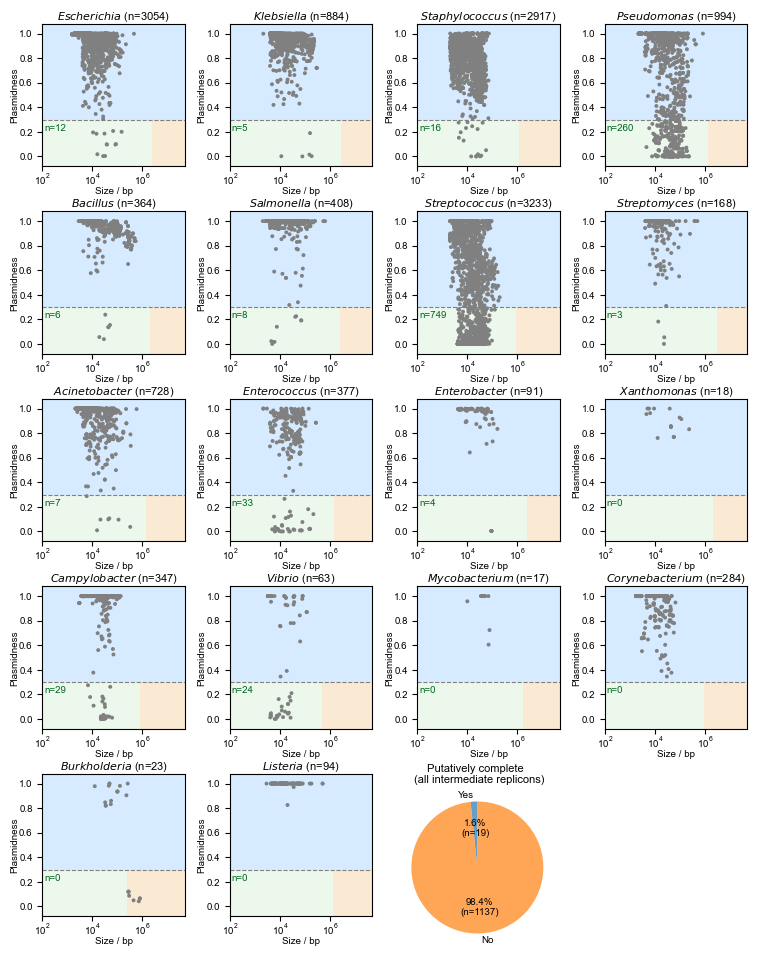

In [4]:
# IMG_PR_result
fig = plt.figure(figsize=(7.5, 7.5))
gap = 0.06
split_size = 1/4
length = split_size - gap

i = 0
all_trasi = []
for genus_name in keep_genus:
    #genus_name = 'Escherichia'
    folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
    contig_info = pd.read_csv(f'{folder}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
    target_dir = rf"/active-data/analysis_results/chr_pla/genus/IMG_PR_plasmid/{genus_name}"
    contig_data = pd.read_csv(f'{target_dir}/IMGPR_plasmid_data.tsv', sep='\t')
    plas_data = pd.read_csv(f'{target_dir}/IMGPR_plasmid_plasmidness.tsv', sep='\t')
    plas_data = plas_data.rename(columns={'contig': 'plasmid_id'})
    merged_data = pd.merge(contig_data, plas_data, on='plasmid_id', how='left')
    merged_data = merged_data[(merged_data['source_type']=='Metagenome')]# & (merged_data['putatively_complete']=='Yes')]
    if merged_data.empty:
        continue

    size_split = process_replicon_data(contig_info)
    filted_data = merged_data[(merged_data['size'] < size_split) & (merged_data['average plasmid fraction-pident_90'] < 0.3)].copy()
    if filted_data.empty:
        pass
    else:
        filted_data['genus']=genus_name
        all_trasi.append(filted_data)
    
    ax1 = fig.add_axes([gap+split_size*(i%4), 1-length-split_size*int(i/4), length, length])
    ax1_n = len(merged_data)
    scatter_figure(ax1, merged_data, f'$\it{{{genus_name}}}$ (n={ax1_n})', contig_info)
    i+=1

all_trasi_pla = pd.concat(all_trasi, ignore_index=True)
add_size = 0.03
ax_complete = fig.add_axes([gap+split_size*(i%4)-add_size, 1-length-split_size*int(i/4)-add_size-0.015, length+add_size, length+add_size])
yes_cnt = (all_trasi_pla['putatively_complete'] == "Yes").sum()
no_cnt  = (all_trasi_pla['putatively_complete'] == "No").sum()
sizes = [yes_cnt, no_cnt]
labels = ["Yes", "No"]

def func_autopct(pct):
    total = sum(sizes)
    val = int(round(pct * total / 100.0))
    return f"{pct:.1f}%\n(n={val})"

ax_complete.pie(
    sizes,
    labels=labels,
    autopct=func_autopct,
    startangle=90,
    wedgeprops={'alpha': 0.7},
)
ax_complete.set_title("Putatively complete \n (all intermediate replicons)", pad=0)

    
os.chdir("/active-data/analysis_results/chr_pla/genus/figures/scatter_plot")
plt.savefig("S_IMG_PR_plasmids_Metagenome_putatively_complete.svg", bbox_inches="tight", transparent=True)
plt.savefig("S_IMG_PR_plasmids_Metagenome_putatively_complete.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()